In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from utils.colors import C3, M, MS
from utils.utils import progress_bar, disk_cache
from utils.solvers import fast_rsvd_solver
from utils.problem_setup import TestProblemsSetup
from utils.metrics import error3
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit

from algorithms.rsvd_solvers import MatrixFreeRSVD
from algorithms.matrix_free_rsvd import get_approximate_W
from algorithms.matrix_free_rsvd import MatrixFreeRSVD as MatrixFreeRSVDOld

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
SETUP = TestProblemsSetup(n=64)
PROBLEMS = SETUP.get_test_problems()
PROBLEM_PARAMS = SETUP.problem_params

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
@disk_cache('../../results/target_rank_error')
def experiment1(
        k_range: np.ndarray,
        p_list: list,
        pid: str,
        repeat: int = 1,
        lam: float = 1e-4,
    ):
    pb = PROBLEMS[pid]
    n_steps, step = len(k_range) * len(p_list) * repeat, 1
    results = []

    rsvd = MatrixFreeRSVD(pb['V_h'])

    for p in p_list:
        for k in k_range:
            for r in range(repeat):
                progress_bar(step, n_steps, end_text=f' [p,k={p},{k}]')
                step += 1

                # Solve inverse problem using matrix-free rSVD
                rsvd.solve(k=k, p=p, seed=SEED + r + p)
                w = rsvd.weights()
                x_hat = rsvd.tikhonov_solve(pb['y'], w, lam)

                # Measure the error
                result = {'p': p, 'k': k}
                result.update(error3(pb['x'], x_hat))
                results.append(result)

    return pd.DataFrame(results)

@disk_cache('../../results/target_rank_error')
def experiment2(pid: str):
    """
    Experiment: measure the weighted Tikhonov solution error.
    """
    pb = PROBLEMS[pid]

    exact = ExactForwardOperator(pb['V_h'])
    f_hat = solve_explicit(
        operator=exact,
        w=exact.get_weights(),
        y=pb['y'],
        lambda_=1e-4
    )
    x_hat = f_hat.vector().get_local()

    results = error3(pb['x'], x_hat)
    return pd.DataFrame([results])



In [4]:
k_range = np.arange(5, 200)
p_list = [0, 5, 10]
repeat = 50

params = [
    {'k_range': k_range, 'p_list': p_list, 'pid': 'I',   'repeat': repeat},
    {'k_range': k_range, 'p_list': p_list, 'pid': 'II',  'repeat': repeat},
    {'k_range': k_range, 'p_list': p_list, 'pid': 'III', 'repeat': repeat},
]

results  = [{'params': p, 'df': experiment1(**p)} for p in params]
exact = {pid: experiment2(pid=pid, force=True) for pid in ['I', 'II', 'III']}

In [5]:
stats = []
for r in results:
    params = r['params']
    df = r['df']
    df_stats = df.groupby(['k', 'p']).agg(
        euclidean     = ('euclidean', 'mean'),
        euclidean_std = ('euclidean', 'std'),
        emd           = ('emd', 'mean'),
        emd_std       = ('emd', 'std'),
        auc_iou       = ('auc_iou', 'mean'),
        auc_iou_std   = ('auc_iou', 'std'),
    ).reset_index()
    stats.append({'params': params, 'df': df_stats})

../../figures/rsvd_over_k_I.png already exists


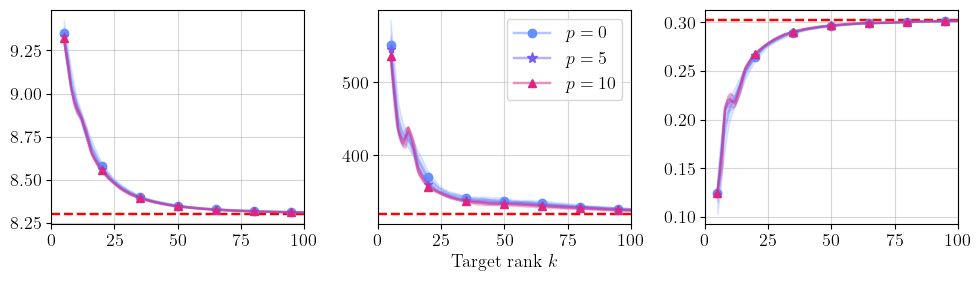

../../figures/rsvd_over_k_II.png already exists


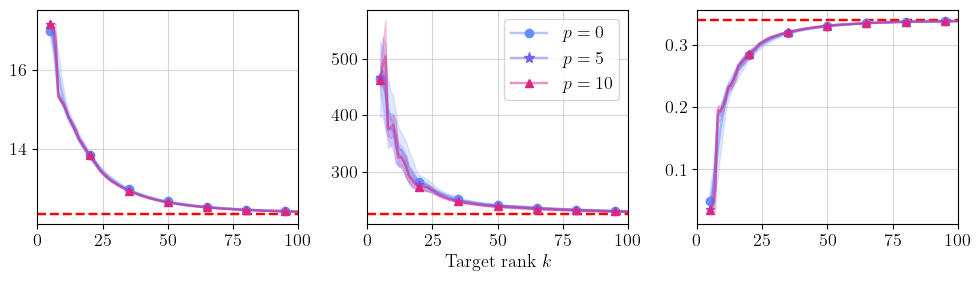

../../figures/rsvd_over_k_III.png already exists


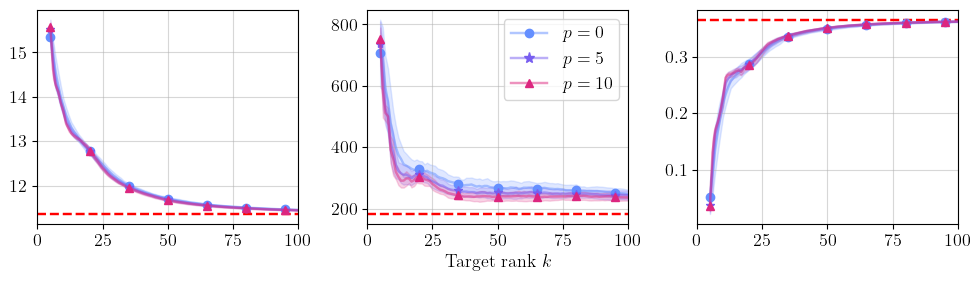

In [6]:
from utils.colors import C3, MS
from utils.plotting import save_plot


def plot_df(df_exact, df_stats, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    s = 15
    m = 100
    metrics = ['euclidean', 'emd', 'auc_iou']
    for i, ax in enumerate(axes.flat):
        ax.axhline(df_exact[metrics[i]].values, lw=1.75, c='r', ls='--')

        for j, p in enumerate(p_list):
            dfj = df_stats[df_stats.p == p]
            ax.plot(dfj.k, dfj[metrics[i]], c=C3[j], lw=1.75, ls='-', alpha=0.5)
            ax.plot(dfj.k[::s], dfj[metrics[i]][::s], M[j], c=C3[j])
            ax.set_xlim(0, m)
            
            ax.fill_between(
                dfj.k,
                dfj[metrics[i]] - dfj[metrics[i] + '_std'],
                dfj[metrics[i]] + dfj[metrics[i] + '_std'],
                color=C3[j],
                alpha=0.2
            )

            ax.grid(True, alpha=.5)

    # Custom legend
    handles, labels = [], []
    for i, p in enumerate(p_list):
        legend_line = Line2D([0], [0], color=C3[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C3[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))
        labels.append(f'$p={p}$')

    axes[1].legend(handles=handles, labels=labels)
    axes[1].set_xlabel('Target rank $k$')

    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


for s in stats:
    pid = s['params']['pid']
    df_exact = exact[pid]
    df_results = s['df']
    plot_df(df_exact, df_results, fig_name=f'rsvd_over_k_{pid}')